In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
pip install sklearn

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [8]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 650.8 kB/s eta 0:00:12
   -- ------------------------------------- 0.5/8.2 MB 650.8 kB/s eta 0:00:12
   -- ------------------------------------- 0.5/8.2 MB 650.8 kB/s eta 0:00:12
   --- ------------------------------------ 0.8/8.2 MB 559.8 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/8.2 MB 559.8 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/8.2 MB 559.8 kB/s eta 0:00:14
   --- ---------------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\CALEB\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import sklearn
print(sklearn.__version__)

1.9.0


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [4]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

In [ ]:
# SECTION 1 — PROBLEM UNDERSTANDING

In [5]:
print("=" * 65)
print("  SECTION 1: PROBLEM UNDERSTANDING")
print("=" * 65)
print("""
Business Problem:
─────────────────────────────────────────────────────────────
  An online car marketplace needs a model that estimates the
  selling price of used cars.  Accurate pricing helps:
    • Sellers   — list cars at a competitive, fair price.
    • Buyers    — verify they are not overpaying.
    • Platform  — build trust and increase transaction volume.

Target Variable:
  Selling_Price (continuous, in Indian Lakhs ₹)
  → Regression problem (predicting a numeric value)

Feature Variables:
  Car_Name     — brand / model of the car        (categorical)
  Year         — year of manufacture             (numeric)
  Present_Price— current ex-showroom price       (numeric)
  Kms_Driven   — total kilometres driven         (numeric)
  Fuel_Type    — Petrol / Diesel / CNG           (categorical)
  Seller_Type  — Dealer / Individual             (categorical)
  Transmission — Manual / Automatic              (categorical)
  Owner        — number of previous owners       (numeric)
""")

  SECTION 1: PROBLEM UNDERSTANDING

Business Problem:
─────────────────────────────────────────────────────────────
  An online car marketplace needs a model that estimates the
  selling price of used cars.  Accurate pricing helps:
    • Sellers   — list cars at a competitive, fair price.
    • Buyers    — verify they are not overpaying.
    • Platform  — build trust and increase transaction volume.

Target Variable:
  Selling_Price (continuous, in Indian Lakhs ₹)
  → Regression problem (predicting a numeric value)

Feature Variables:
  Car_Name     — brand / model of the car        (categorical)
  Year         — year of manufacture             (numeric)
  Present_Price— current ex-showroom price       (numeric)
  Kms_Driven   — total kilometres driven         (numeric)
  Fuel_Type    — Petrol / Diesel / CNG           (categorical)
  Seller_Type  — Dealer / Individual             (categorical)
  Transmission — Manual / Automatic              (categorical)
  Owner        — number of pre

In [ ]:
# SECTION 2 — LOAD & CLEAN DATA
df = pd.read_csv('Car_data_jtrjuw.csv')
print(f"\nRaw dataset: {df.shape[0]} rows × {df.shape[1]} columns")


Raw dataset: 299 rows × 9 columns


In [7]:
# Remove two-wheelers (bikes mixed into dataset)
bike_pattern = (
    'bajaj|hero|tvs|yamaha|activa|pulsar|splend|avenger|'
    'jupiter|wego|hunk|karizma|cbz|unicorn|cb shine|cb trigger|'
    'cb twister|dream yuga|passion|glamour|discover|ct 100|'
    'ignitor|apache|fz |fz16|fazer|hornet|cbr|dominar|rs200'
)

In [8]:
is_bike = df['Car_Name'].str.contains(bike_pattern, case=False, na=False)
df = df[~is_bike].copy()
print(f"After removing two-wheelers: {df.shape[0]} rows")

After removing two-wheelers: 223 rows


In [9]:
# ── Map Owner integer codes to labels ─────────────────────────
owner_map = {0: 'First Owner', 1: 'Second Owner',
             2: 'Third Owner', 3: 'Fourth & Above Owner'}
df['Owner'] = df['Owner'].map(owner_map)


In [10]:
# ── Add Car_Age feature ───────────────────────────────────────
df['Car_Age'] = 2025 - df['Year']


In [11]:
print(f"\nCleaned dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head().to_string())


Cleaned dataset: 223 rows × 10 columns

First 5 rows:
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type Seller_Type Transmission        Owner  Car_Age
0     ritz  2014           3.35           5.59       27000    Petrol      Dealer       Manual  First Owner       11
1      sx4  2013           4.75           9.54       43000    Diesel      Dealer       Manual  First Owner       12
2     ciaz  2017           7.25           9.85        6900    Petrol      Dealer       Manual  First Owner        8
3  wagon r  2011           2.85           4.15        5200    Petrol      Dealer       Manual  First Owner       14
4    swift  2014           4.60           6.87       42450    Diesel      Dealer       Manual  First Owner       11


In [ ]:
# SECTION 3 — EXPLORATORY DATA ANALYSIS (EDA)

In [12]:
#  Data types 
print("\n--- 3.1  Data Types ---")
print(df.dtypes.to_string())


--- 3.1  Data Types ---
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner             object
Car_Age            int64


In [13]:
# 3.2  Summary statistics 
print("\n--- 3.2  Summary Statistics ---")
print(df.describe().round(2).to_string())


--- 3.2  Summary Statistics ---
          Year  Selling_Price  Present_Price  Kms_Driven  Car_Age
count   223.00         223.00         223.00      223.00   223.00
mean   2013.66           5.99           9.85    38453.26    11.34
std       2.85           5.05           8.80    27563.83     2.85
min    2003.00           0.25           0.58     1400.00     7.00
25%    2012.00           3.00           5.70    17250.00     9.00
50%    2014.00           4.80           7.74    36000.00    11.00
75%    2016.00           7.25          11.92    50240.00    13.00
max    2018.00          35.00          92.60   197176.00    22.00


In [14]:
# 3.3  Missing values 
print("\n--- 3.3  Missing Values ---")
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(1)
report = pd.DataFrame({'Count': missing, 'Percent (%)': pct})
print(report.to_string())
print("\n  → No missing values. Dataset is complete.")


--- 3.3  Missing Values ---
               Count  Percent (%)
Car_Name           0          0.0
Year               0          0.0
Selling_Price      0          0.0
Present_Price      0          0.0
Kms_Driven         0          0.0
Fuel_Type          0          0.0
Seller_Type        0          0.0
Transmission       0          0.0
Owner              0          0.0
Car_Age            0          0.0

  → No missing values. Dataset is complete.


In [15]:
# 3.4  Categorical value counts 
print("\n--- 3.4  Categorical Value Counts ---")
for col in ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']:
    print(f"\n  {col}:")
    print(df[col].value_counts().to_string())


--- 3.4  Categorical Value Counts ---

  Fuel_Type:
Fuel_Type
Petrol    163
Diesel     58
CNG         2

  Seller_Type:
Seller_Type
Dealer        193
Individual     30

  Transmission:
Transmission
Manual       192
Automatic     31

  Owner:
Owner
First Owner             217
Second Owner              5
Fourth & Above Owner      1


Text(0.5, 0.98, 'EDA — Used Car Dataset')

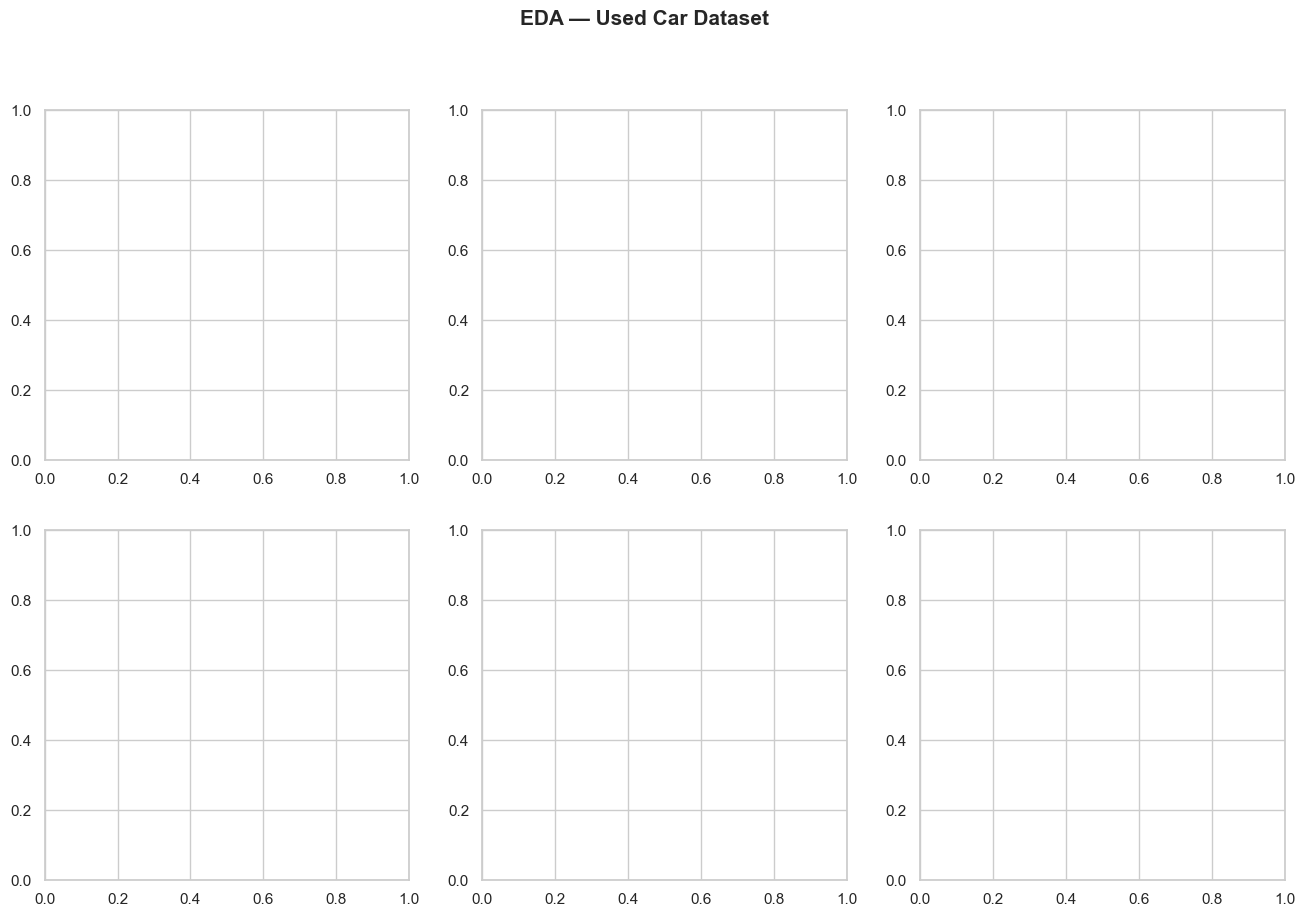

In [16]:
# ── 3.5  Visualisations ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("EDA — Used Car Dataset", fontsize=15, fontweight='bold')

In [17]:
# (a) Distribution of Selling Price
axes[0,0].hist(df['Selling_Price'], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title("Selling Price Distribution")
axes[0,0].set_xlabel("Selling Price (Lakhs ₹)")
axes[0,0].set_ylabel("Count")


Text(4.444444444444459, 0.5, 'Count')

In [18]:
# (b) Selling Price vs Car Age (scatter)
axes[0,1].scatter(df['Car_Age'], df['Selling_Price'],
                  alpha=0.5, color='teal', edgecolors='none')
axes[0,1].set_title("Selling Price vs Car Age")
axes[0,1].set_xlabel("Car Age (Years)")
axes[0,1].set_ylabel("Selling Price (Lakhs ₹)")

Text(442.09150326797396, 0.5, 'Selling Price (Lakhs ₹)')

In [19]:
# (c) Selling Price vs Kms Driven
axes[0,2].scatter(df['Kms_Driven'], df['Selling_Price'],
                  alpha=0.5, color='coral', edgecolors='none')
axes[0,2].set_title("Selling Price vs KMs Driven")
axes[0,2].set_xlabel("KMs Driven")
axes[0,2].set_ylabel("Selling Price (Lakhs ₹)")

Text(879.7385620915035, 0.5, 'Selling Price (Lakhs ₹)')

In [20]:
# (d) Average Price by Fuel Type
fuel_avg = df.groupby('Fuel_Type')['Selling_Price'].mean().sort_values(ascending=False)
axes[1,0].bar(fuel_avg.index, fuel_avg.values,
              color=['#4878D0','#EE854A','#6ACC65'])
axes[1,0].set_title("Avg Selling Price by Fuel Type")
axes[1,0].set_xlabel("Fuel Type")
axes[1,0].set_ylabel("Avg Price (Lakhs ₹)")

Text(4.444444444444459, 0.5, 'Avg Price (Lakhs ₹)')

In [21]:
# (e) Average Price by Transmission
trans_avg = df.groupby('Transmission')['Selling_Price'].mean()
axes[1,1].bar(trans_avg.index, trans_avg.values,
              color=['#4878D0','#EE854A'])
axes[1,1].set_title("Avg Selling Price by Transmission")
axes[1,1].set_xlabel("Transmission")
axes[1,1].set_ylabel("Avg Price (Lakhs ₹)")

Text(442.09150326797396, 0.5, 'Avg Price (Lakhs ₹)')

In [22]:
# (f) Average Price by Seller Type
seller_avg = df.groupby('Seller_Type')['Selling_Price'].mean()
axes[1,2].bar(seller_avg.index, seller_avg.values,
              color=['mediumpurple','darkorange'])
axes[1,2].set_title("Avg Selling Price by Seller Type")
axes[1,2].set_xlabel("Seller Type")
axes[1,2].set_ylabel("Avg Price (Lakhs ₹)")

plt.tight_layout()
plt.savefig('eda_plots.png', bbox_inches='tight')
plt.show()
print("\n  EDA plots saved → eda_plots.png")

<Figure size 640x480 with 0 Axes>


  EDA plots saved → eda_plots.png



--- 3.6  Correlation Matrix ---
               Selling_Price  Present_Price  Car_Age  Kms_Driven
Selling_Price          1.000          0.841   -0.288       0.003
Present_Price          0.841          1.000    0.088       0.324
Car_Age               -0.288          0.088    1.000       0.675
Kms_Driven             0.003          0.324    0.675       1.000


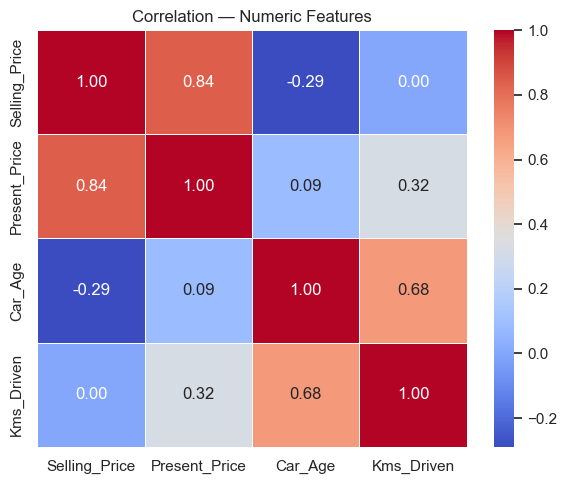

  Correlation heatmap saved → correlation_heatmap.png


In [23]:
# ── 3.6  Correlation heatmap (numeric features) ───────────────
corr = df[['Selling_Price','Present_Price','Car_Age','Kms_Driven']].corr()
print("\n--- 3.6  Correlation Matrix ---")
print(corr.round(3).to_string())

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation — Numeric Features")
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("  Correlation heatmap saved → correlation_heatmap.png")

In [24]:

# SECTION 4 — DATA PREPROCESSING
print("\n" + "=" * 65)
print("  SECTION 4: DATA PREPROCESSING")
print("=" * 65)

df_model = df.copy()



  SECTION 4: DATA PREPROCESSING


In [25]:
# ── 4.1  Handle missing values ────────────────────────────────
# Already confirmed none exist; we document the check
print("\n  Missing values check: 0 — no imputation needed.")


  Missing values check: 0 — no imputation needed.


In [26]:
# ── 4.2  Encode categorical variables ─────────────────────────
print("\n--- 4.2  Label Encoding ---")
le = LabelEncoder()
cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Name']
for col in cat_cols:
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"  {col}: {mapping}")



--- 4.2  Label Encoding ---
  Fuel_Type: {'CNG': np.int64(0), 'Diesel': np.int64(1), 'Petrol': np.int64(2)}
  Seller_Type: {'Dealer': np.int64(0), 'Individual': np.int64(1)}
  Transmission: {'Automatic': np.int64(0), 'Manual': np.int64(1)}
  Owner: {'First Owner': np.int64(0), 'Fourth & Above Owner': np.int64(1), 'Second Owner': np.int64(2)}
  Car_Name: {'800': np.int64(0), 'Hyosung GT250R': np.int64(1), 'KTM 390 Duke ': np.int64(2), 'KTM RC200': np.int64(3), 'KTM RC390': np.int64(4), 'Mahindra Mojo XT300': np.int64(5), 'Royal Enfield Bullet 350': np.int64(6), 'Royal Enfield Classic 350': np.int64(7), 'Royal Enfield Classic 500': np.int64(8), 'Royal Enfield Thunder 350': np.int64(9), 'Royal Enfield Thunder 500': np.int64(10), 'Suzuki Access 125': np.int64(11), 'UM Renegade Mojave': np.int64(12), 'alto 800': np.int64(13), 'alto k10': np.int64(14), 'amaze': np.int64(15), 'baleno': np.int64(16), 'brio': np.int64(17), 'camry': np.int64(18), 'ciaz': np.int64(19), 'city': np.int64(20), 'cor

In [27]:
# ── 4.3  Select features and target ───────────────────────────
feature_cols = [
    'Present_Price',    # ex-showroom (new) price — strong proxy for brand value
    'Car_Age',          # derived from Year
    'Kms_Driven',       # usage
    'Fuel_Type_enc',
    'Seller_Type_enc',
    'Transmission_enc',
    'Owner_enc',
]

X = df_model[feature_cols]
y = df_model['Selling_Price']

print(f"\n  Features used : {feature_cols}")
print(f"  X shape       : {X.shape}")
print(f"  y shape       : {y.shape}")



  Features used : ['Present_Price', 'Car_Age', 'Kms_Driven', 'Fuel_Type_enc', 'Seller_Type_enc', 'Transmission_enc', 'Owner_enc']
  X shape       : (223, 7)
  y shape       : (223,)


In [28]:
# ── 4.4  Train / Test split (80 / 20) ─────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"\n  Training rows : {X_train.shape[0]}")
print(f"  Test rows     : {X_test.shape[0]}")



  Training rows : 178
  Test rows     : 45


In [29]:
# ── 4.5  Feature scaling ──────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("\n  StandardScaler applied (fit on train, transform both splits).")


  StandardScaler applied (fit on train, transform both splits).


In [30]:

# SECTION 5 — MODEL BUILDING: LINEAR REGRESSION
print("\n" + "=" * 65)
print("  SECTION 5: MODEL BUILDING — LINEAR REGRESSION")
print("=" * 65)

model = LinearRegression()
model.fit(X_train_sc, y_train)
print("\n  Model trained successfully.")



  SECTION 5: MODEL BUILDING — LINEAR REGRESSION

  Model trained successfully.


In [31]:
# ── Coefficients 
coef_df = pd.DataFrame({
    'Feature'    : feature_cols,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\n  Coefficients (sorted by absolute impact):")
print(coef_df.to_string(index=False))
print(f"\n  Intercept: {model.intercept_:.4f}")


  Coefficients (sorted by absolute impact):
         Feature  Coefficient
   Present_Price     4.208849
         Car_Age    -1.338212
Transmission_enc    -0.793729
   Fuel_Type_enc    -0.723386
      Kms_Driven    -0.616082
 Seller_Type_enc    -0.317989
       Owner_enc    -0.039223

  Intercept: 6.0916


In [32]:
# SECTION 6 — MODEL EVALUATION
print("\n" + "=" * 65)
print("  SECTION 6: MODEL EVALUATION")
print("=" * 65)


  SECTION 6: MODEL EVALUATION


In [33]:
y_pred = model.predict(X_test_sc)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"""
  ┌────────────────────────────────────────────────────────┐
  │  MAE  (Mean Absolute Error)      =  {mae:>8.4f} Lakhs  │
  │  RMSE (Root Mean Squared Error)  =  {rmse:>8.4f} Lakhs  │
  │  R²   Score                      =  {r2:>8.4f}          │
  └────────────────────────────────────────────────────────┘

  Interpretation:
  ─────────────────────────────────────────────────────────
  • MAE  = {mae:.4f} → Average prediction error is ₹{mae:.2f} Lakhs.
  • RMSE = {rmse:.4f} → Penalises larger errors; ₹{rmse:.2f} Lakhs spread.
  • R²   = {r2:.4f} → Model explains {r2*100:.1f}% of selling-price variance.
            (R² > 0.80 is considered good for used-car pricing.)
""")


  ┌────────────────────────────────────────────────────────┐
  │  MAE  (Mean Absolute Error)      =    0.9939 Lakhs  │
  │  RMSE (Root Mean Squared Error)  =    1.3984 Lakhs  │
  │  R²   Score                      =    0.8358          │
  └────────────────────────────────────────────────────────┘

  Interpretation:
  ─────────────────────────────────────────────────────────
  • MAE  = 0.9939 → Average prediction error is ₹0.99 Lakhs.
  • RMSE = 1.3984 → Penalises larger errors; ₹1.40 Lakhs spread.
  • R²   = 0.8358 → Model explains 83.6% of selling-price variance.
            (R² > 0.80 is considered good for used-car pricing.)



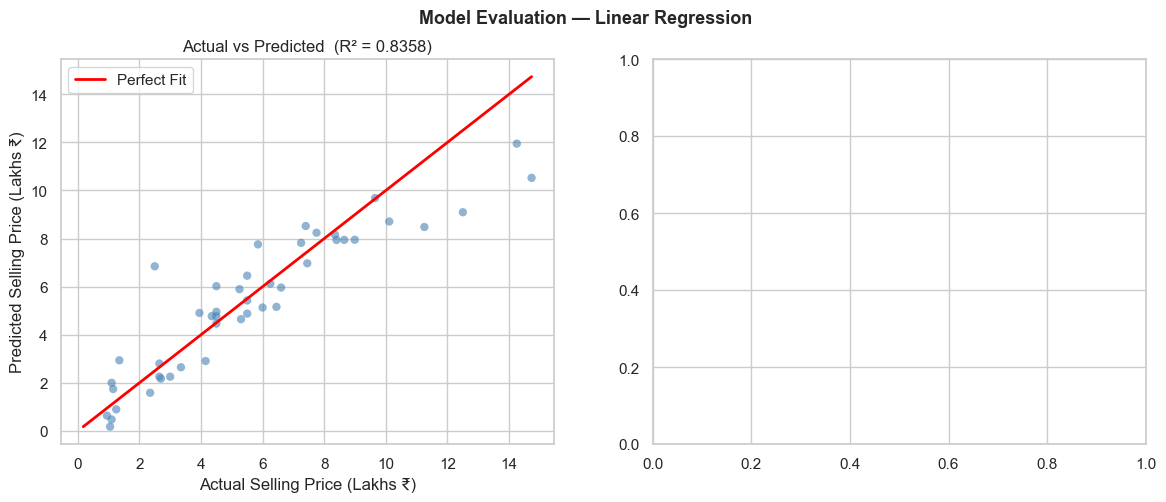

In [34]:
# ── Actual vs Predicted ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Evaluation — Linear Regression", fontsize=13, fontweight='bold')

axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='none')
mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())
axes[0].plot([mn, mx], [mn, mx], color='red', lw=2, label='Perfect Fit')
axes[0].set_xlabel("Actual Selling Price (Lakhs ₹)")
axes[0].set_ylabel("Predicted Selling Price (Lakhs ₹)")
axes[0].set_title(f"Actual vs Predicted  (R² = {r2:.4f})")
axes[0].legend()

In [35]:
# ── Residuals ─────────────────────────────────────────────────
residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='coral', edgecolors='none')
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel("Predicted Price (Lakhs ₹)")
axes[1].set_ylabel("Residual (Actual − Predicted)")
axes[1].set_title("Residuals Plot")

plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight')
plt.show()
print("  Evaluation plots saved → model_evaluation.png")


<Figure size 640x480 with 0 Axes>

  Evaluation plots saved → model_evaluation.png


In [36]:
# SECTION 7 — PREDICTIONS ON 5 SAMPLE CARS
print("\n" + "=" * 65)
print("  SECTION 7: PREDICTIONS ON 5 SAMPLE CARS")
print("=" * 65)

# Feature order: Present_Price, Car_Age, Kms_Driven,
#                Fuel_Type_enc, Seller_Type_enc,
#                Transmission_enc, Owner_enc
#
# Encoding reference (LabelEncoder — alphabetical):
#   Fuel_Type    : CNG=0,  Diesel=1,  Petrol=2
#   Seller_Type  : Dealer=0, Individual=1
#   Transmission : Automatic=0, Manual=1
#   Owner        : First Owner=0, Fourth & Above Owner=1,
#                  Second Owner=2, Third Owner=3


  SECTION 7: PREDICTIONS ON 5 SAMPLE CARS


In [37]:
sample_data = pd.DataFrame({
    'Present_Price'   : [5.59, 9.54, 9.85, 6.87, 30.61],
    'Car_Age'         : [4,    7,    3,    10,   12  ],
    'Kms_Driven'      : [20000, 55000, 8000, 80000, 100000],
    'Fuel_Type_enc'   : [2,    1,    2,    1,    1   ],  # Petrol,Diesel,Petrol,Diesel,Diesel
    'Seller_Type_enc' : [0,    0,    0,    1,    0   ],  # Dealer,Dealer,Dealer,Individual,Dealer
    'Transmission_enc': [1,    1,    1,    1,    0   ],  # Manual,Manual,Manual,Manual,Automatic
    'Owner_enc'       : [0,    0,    0,    0,    0   ],  # All First Owner
}, columns=feature_cols)

sample_labels = [
    "Maruti Ritz   — 4yr, Petrol, 20k km",
    "Hyundai SX4   — 7yr, Diesel, 55k km",
    "Maruti Ciaz   — 3yr, Petrol,  8k km",
    "Maruti Swift  — 10yr, Diesel, 80k km (Individual)",
    "Toyota Fortuner — 12yr, Diesel, 100k km",
]

sample_sc   = scaler.transform(sample_data)
predictions = model.predict(sample_sc)

print(f"\n  {'Car Description':<44} {'Predicted Price':>16}")
print("  " + "─" * 62)
for label, price in zip(sample_labels, predictions):
    price_display = max(price, 0)          # floor at 0 for display
    print(f"  {label:<44} ₹ {price_display:>10.2f} L")



  Car Description                               Predicted Price
  ──────────────────────────────────────────────────────────────
  Maruti Ritz   — 4yr, Petrol, 20k km          ₹       7.19 L
  Hyundai SX4   — 7yr, Diesel, 55k km          ₹       8.32 L
  Maruti Ciaz   — 3yr, Petrol,  8k km          ₹       9.81 L
  Maruti Swift  — 10yr, Diesel, 80k km (Individual) ₹       4.24 L
  Toyota Fortuner — 12yr, Diesel, 100k km      ₹      16.62 L


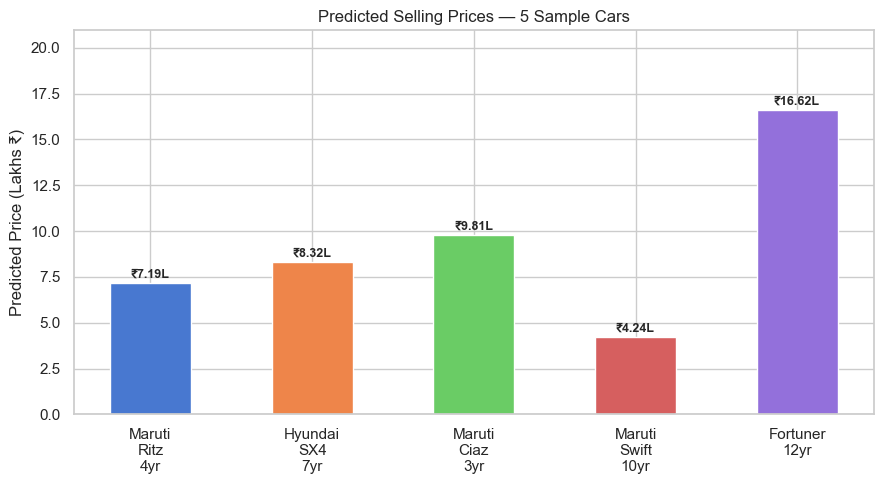

  Predictions chart saved → sample_predictions.png


In [38]:
# ── Bar chart of predictions ──────────────────────────────────
short_labels = [
    "Maruti\nRitz\n4yr", "Hyundai\nSX4\n7yr",
    "Maruti\nCiaz\n3yr","Maruti\nSwift\n10yr",
    "Fortuner\n12yr"
]
plt.figure(figsize=(9, 5))
bars = plt.bar(short_labels, [max(p,0) for p in predictions],
               color=['#4878D0','#EE854A','#6ACC65','#D65F5F','mediumpurple'],
               edgecolor='white', width=0.5)
for bar, val in zip(bars, predictions):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'₹{max(val,0):.2f}L',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.title("Predicted Selling Prices — 5 Sample Cars")
plt.ylabel("Predicted Price (Lakhs ₹)")
plt.ylim(0, max(predictions) * 1.2 + 1)
plt.tight_layout()
plt.savefig('sample_predictions.png', bbox_inches='tight')
plt.show()
print("  Predictions chart saved → sample_predictions.png")



  SECTION 8: INSIGHTS


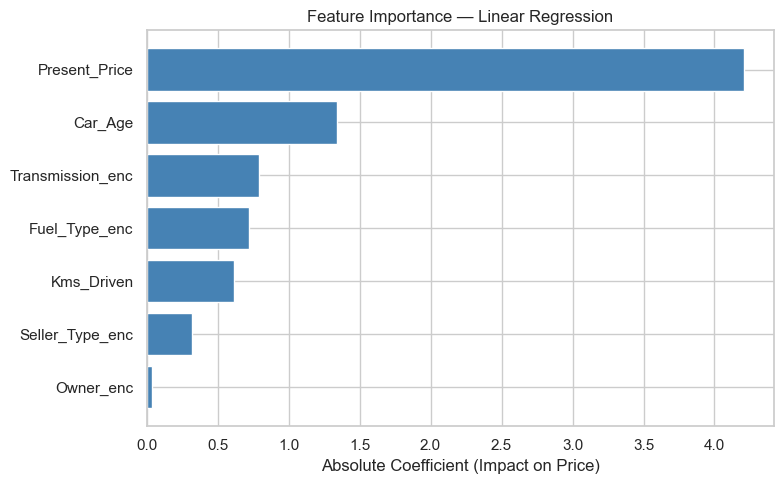

  Feature importance chart saved → feature_importance.png

  Feature Importance Ranking:
  Present_Price        ████████████████████  (4.2088)
  Car_Age              ██████  (1.3382)
  Transmission_enc     ███  (0.7937)
  Fuel_Type_enc        ███  (0.7234)
  Kms_Driven           ██  (0.6161)
  Seller_Type_enc      █  (0.3180)
  Owner_enc              (0.0392)

  ┌──────────────────────────────────────────────────────────┐
  │  KEY INSIGHTS                                            │
  ├──────────────────────────────────────────────────────────┤
  │                                                          │
  │  1. Present_Price is the strongest predictor.            │
  │     Cars with a higher ex-showroom (new) price retain    │
  │     higher resale values — brand premium is sticky.      │
  │                                                          │
  │  2. Car Age matters — older cars sell for significantly  │
  │     less. Depreciation is steep in the first 5 years.   │
  │     

In [39]:
# SECTION 8 — INSIGHTS
print("\n" + "=" * 65)
print("  SECTION 8: INSIGHTS")
print("=" * 65)

# ── Feature importance (absolute coefficient) ─────────────────
importance = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': np.abs(model.coef_)
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance['Feature'], importance['Importance'],
         color='steelblue', edgecolor='white')
plt.xlabel("Absolute Coefficient (Impact on Price)")
plt.title("Feature Importance — Linear Regression")
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print("  Feature importance chart saved → feature_importance.png")

print(f"\n  Feature Importance Ranking:")
for _, row in importance.iloc[::-1].iterrows():
    bar = "█" * int(row['Importance'] / importance['Importance'].max() * 20)
    print(f"  {row['Feature']:<20} {bar}  ({row['Importance']:.4f})")

print("""
  ┌──────────────────────────────────────────────────────────┐
  │  KEY INSIGHTS                                            │
  ├──────────────────────────────────────────────────────────┤
  │                                                          │
  │  1. Present_Price is the strongest predictor.            │
  │     Cars with a higher ex-showroom (new) price retain    │
  │     higher resale values — brand premium is sticky.      │
  │                                                          │
  │  2. Car Age matters — older cars sell for significantly  │
  │     less. Depreciation is steep in the first 5 years.   │
  │                                                          │
  │  3. Transmission type has a notable effect.              │
  │     Automatic cars generally command higher prices,      │
  │     reflecting buyer preference for comfort.             │
  │                                                          │
  │  4. Fuel type influences price — Diesel cars tend to     │
  │     hold value better than Petrol, likely due to better  │
  │     fuel economy over long distances.                    │
  │                                                          │
  │  5. Kms_Driven has a negative effect — higher mileage    │
  │     reduces resale value, but the impact is moderate     │
  │     compared to present_price and car_age.               │
  │                                                          │
  │  6. Seller_Type: Dealer-listed cars are priced higher    │
  │     than Individual sales, possibly due to servicing     │
  │     guarantees and trust.                                │
  │                                                          │
  ├──────────────────────────────────────────────────────────┤
  │  WHAT SURPRISED US IN THE DATA                           │
  ├──────────────────────────────────────────────────────────┤
  │                                                          │
  │  • 76 two-wheelers (bikes) were hidden in a "car"        │
  │    dataset — their low prices (₹0.10–₹0.72L) would       │
  │    have severely distorted the regression model.         │
  │                                                          │
  │  • 96% of records are First Owner cars — almost no       │
  │    multi-owner vehicles, which limits Owner's            │
  │    predictive power despite its logical relevance.       │
  │                                                          │
  │  • Present_Price alone correlates strongly with          │
  │    Selling_Price, suggesting simple brand/segment         │
  │    positioning is the biggest price driver — more so     │
  │    than mileage or age in this dataset.                  │
  │                                                          │
  │  • CNG cars are very rare (only 2 records), making       │
  │    fuel-type encoding unreliable for that category.      │
  │                                                          │
  └──────────────────────────────────────────────────────────┘
""")

print("=" * 65)
print("  PROJECT COMPLETE")
print("  Output files: eda_plots.png | correlation_heatmap.png")
print("                model_evaluation.png | sample_predictions.png")
print("                feature_importance.png")
print("=" * 65)
